# From Core Python to NumPy to C

The first notebook introduces Python programming, NumPy arrays, floating-point arithmetic, truncation error, round-off error, accuracy, and precision. This notebook now takes one numerical operation and studies how the same mathematical idea appears in Python, NumPy, and C.

The central example is matrix multiplication.

The objective is to explain three things:

1. how matrix multiplication is written as an algorithm,
2. why pure Python loops are slow compared with NumPy and C,
3. why memory layout can change performance even when the mathematics is unchanged.

> Numerical programming is not only about writing/translating formulas into computer language. It is also about representing data and moving data efficiently through memory.


## One simple mathematical problem, many implementations

NumPy makes array programming look very simple. For example, matrix multiplication can be written as

```python
C = A @ B
```

But this one line hides a serious numerical computation.

In this notebook, we implement the same matrix multiplication idea in four ways:

1. **Core Python loops** — clear and close to pseudocode, but slow.
2. **NumPy** — short syntax, compiled library underneath.
3. **C with fixed-size arrays** — explicit compiled code for a small matrix.
4. **C with contiguous dynamic arrays** — closer to real high-performance code.

We will also compare normal C matrix multiplication with a cache-friendlier transposed version.


## Matrix multiplication as an algorithm

For two square matrices $A$ and $B$, the matrix product $C = AB$ is defined component-wise as

$$
C_{ij} = \sum_{k=0}^{N-1} A_{ik}B_{kj}.
$$

This means:

- choose row $i$ of $A$,
- choose column $j$ of $B$,
- multiply corresponding entries,
- sum the products.

For an $N \times N$ matrix multiplication, there are $N^2$ entries in $C$. Each entry requires a sum over $N$ terms. Therefore, the operation count scales approximately as

$$
O(N^3).
$$

For $N=1000$, this is of the order of

$$
1000^3 = 10^9
$$

multiply-add operations. Therefore, implementation matters.


## Pseudocode

The algorithm can be written as:

```text
for i = 0 to N-1:
    for j = 0 to N-1:
        sum = 0
        for k = 0 to N-1:
            sum = sum + A[i,k] * B[k,j]
        C[i,j] = sum
```

This is the most important step.

Once we understand this algorithm, Python, C, NumPy, and even CUDA are different ways of expressing or accelerating the same computation.


## Core Python implementation

We first write matrix multiplication using ordinary Python lists.

This version is useful because it exposes the algorithm directly. It is not intended to be fast.


In [1]:
def matmul_python(A, B):
    N = len(A)
    C = [[0.0 for j in range(N)] for i in range(N)]

    for i in range(N):
        for j in range(N):
            s = 0.0
            for k in range(N):
                s += A[i][k] * B[k][j]
            C[i][j] = s

    return C


A = [[1.0, 2.0],
     [3.0, 4.0]]

B = [[5.0, 6.0],
     [7.0, 8.0]]

C = matmul_python(A, B)
print(C)


[[19.0, 22.0], [43.0, 50.0]]


Expected output:

```text
[[19.0, 22.0], [43.0, 50.0]]
```

The code is easy to read. It is excellent for understanding the algorithm.

But it is slow for large matrices because every loop iteration is handled by the Python interpreter.

> Pure Python: one number at a time.
> NumPy: many numbers at once.

A useful analogy is:

> Pure Python is like filling a large tank one cup of water at a time.
> NumPy is like filling the tank using a pipe.
> Both fill the tank, but the pipe is much faster because it moves many small amounts together.




## NumPy implementation

Now we use NumPy.

The code is shorter, but the mathematical operation is the same.


In [2]:
import numpy as np

A_np = np.array([[1.0, 2.0],
                 [3.0, 4.0]])

B_np = np.array([[5.0, 6.0],
                 [7.0, 8.0]])

C_np = A_np @ B_np
print(C_np)


[[19. 22.]
 [43. 50.]]


NumPy looks like Python, but the heavy operation `A @ B` is not executed as slow Python loops.

For dense matrix multiplication, NumPy usually calls optimized compiled libraries such as BLAS-type routines.

| Version | Student sees | What happens underneath |
|---|---|---|
| Core Python | loops over lists | interpreted loop overhead |
| C | loops over contiguous memory | compiled machine code |
| NumPy | `A @ B` | optimized compiled library underneath made using C, BLAS |

Important nuance:

> C is not automatically faster than NumPy. C gives control. NumPy gives access to highly optimized compiled kernels. Naive C matrix multiplication can be slower than NumPy.


## C programming essentials needed for this example

Before reading the C code, recall a few important differences between Python and C.

### Python and C share the same basic logic

Both languages can use:

- variables,
- `if` statements,
- `for` loops,
- functions.

But they differ in execution model and memory handling.

| Feature | Python | C |
|---|---|---|
| Execution | interpreted | compiled |
| Typing | dynamic | static |
| Memory | mostly automatic | programmer controlled |
| Arrays | flexible objects | contiguous memory blocks |
| Debugging risk | usually runtime error messages | possible segmentation faults and memory bugs |

The advantage of C is control. The danger of C is also control.


## C implementation using fixed-size arrays

We now write the same matrix multiplication in C.
This first version uses fixed-size arrays. There is no dynamic memory allocation yet. Let us first understand the loop structure. 


In [3]:
%%writefile matmul_fixed.c
#include <stdio.h>

#define N 2

int main() {
    double A[N][N] = {
        {1.0, 2.0},
        {3.0, 4.0}
    };

    double B[N][N] = {
        {5.0, 6.0},
        {7.0, 8.0}
    };

    double C[N][N];

    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            double sum = 0.0;
            for (int k = 0; k < N; k++) {
                sum += A[i][k] * B[k][j];
            }
            C[i][j] = sum;
        }
    }

    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            printf("%8.2f ", C[i][j]);
        }
        printf("\n");
    }

    return 0;
}


Overwriting matmul_fixed.c


In [4]:
!gcc matmul_fixed.c -o matmul_fixed
!./matmul_fixed


   19.00    22.00 
   43.00    50.00 


Important points to notice:

- C syntax is longer than Python syntax.
- Variables have declared types.
- The loops are explicit.
- The algorithm is exactly the same as the Python version.
- The program must be compiled before it is run.

This version is not difficult. But as soon as the matrix size is not known beforehand, we need dynamic memory allocation.


## C arrays as contiguous memory

In mathematics, a matrix is written as a two-dimensional object:

$$
A_{ij}.
$$

But computer memory is one-dimensional. A two-dimensional array is stored as a long sequence of numbers.

For row-major storage, the mapping is

$$
A_{ij} \rightarrow A[iN+j].
$$

For a $3 \times 3$ matrix,

$$
\begin{bmatrix}
A_{00} & A_{01} & A_{02}\\
A_{10} & A_{11} & A_{12}\\
A_{20} & A_{21} & A_{22}
\end{bmatrix}
$$

is stored as

```text
A00  A01  A02  A10  A11  A12  A20  A21  A22
```

So the memory index is

```c
A[i*N + j]
```

This mapping is foundational for high-performance C, CUDA, and many numerical libraries.


## C implementation using `malloc` and one-dimensional contiguous arrays

Now we write a more realistic C version.

Each matrix is stored as a one-dimensional contiguous block of memory. We manually convert two-dimensional indices to one-dimensional indices using

$$
(i,j) \rightarrow iN+j.
$$


In [5]:
%%writefile matmul_malloc.c
#include <stdio.h>
#include <stdlib.h>

#define IDX(i, j, N) ((i) * (N) + (j))

void matmul(int N, double *A, double *B, double *C) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            double sum = 0.0;
            for (int k = 0; k < N; k++) {
                sum += A[IDX(i, k, N)] * B[IDX(k, j, N)];
            }
            C[IDX(i, j, N)] = sum;
        }
    }
}

int main() {
    int N = 2;

    double *A = malloc((size_t)N * N * sizeof(double));
    double *B = malloc((size_t)N * N * sizeof(double));
    double *C = malloc((size_t)N * N * sizeof(double));

    if (A == NULL || B == NULL || C == NULL) {
        printf("Memory allocation failed.\n");
        free(A);
        free(B);
        free(C);
        return 1;
    }

    A[IDX(0, 0, N)] = 1.0;
    A[IDX(0, 1, N)] = 2.0;
    A[IDX(1, 0, N)] = 3.0;
    A[IDX(1, 1, N)] = 4.0;

    B[IDX(0, 0, N)] = 5.0;
    B[IDX(0, 1, N)] = 6.0;
    B[IDX(1, 0, N)] = 7.0;
    B[IDX(1, 1, N)] = 8.0;

    matmul(N, A, B, C);

    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            printf("%8.2f ", C[IDX(i, j, N)]);
        }
        printf("\n");
    }

    free(A);
    free(B);
    free(C);

    return 0;
}


Overwriting matmul_malloc.c


In [6]:
!gcc matmul_malloc.c -o matmul_malloc
!./matmul_malloc


   19.00    22.00 
   43.00    50.00 


Teaching points:

- `malloc` allocates memory at runtime.
- `free` releases memory.
- `double *A` is a pointer to a block of `double` values.
- We manually convert two-dimensional indices to one-dimensional indices.
- This is powerful, but it introduces more ways to make mistakes.

Important warning:

> In C, the computer trusts you more. That is both the advantage and the danger.


## Timing comparison: core Python, C, and NumPy

We now compare three implementations of the same matrix multiplication idea:

1. core Python loops,
2. C loops compiled with optimization,
3. NumPy matrix multiplication.

We also compare two C implementations:

1. normal C multiplication,
2. C multiplication after transposing $B$.

The purpose is not just to see which one is faster. The purpose is to understand why the same mathematical operation can have different computational cost depending on implementation.

**Practical note:** The following C benchmark requires a C compiler. On Linux, `gcc` is usually available. On macOS, `clang` is usually available.


In [7]:
%%writefile matmul_c_benchmark.c
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

#define IDX(i,j,N) ((i)*(N)+(j))

double elapsed_seconds(struct timespec start, struct timespec end) {
    return (end.tv_sec - start.tv_sec) + 1.0e-9 * (end.tv_nsec - start.tv_nsec);
}

void fill_matrices(int N, double *A, double *B) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            A[IDX(i,j,N)] = 1.0 / (1.0 + i + j);
            B[IDX(i,j,N)] = 1.0 / (1.0 + i + 2*j);
        }
    }
}

void zero_matrix(int N, double *C) {
    for (int i = 0; i < N * N; i++) {
        C[i] = 0.0;
    }
}

void transpose(int N, double *B, double *BT) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            BT[IDX(j,i,N)] = B[IDX(i,j,N)];
        }
    }
}

void matmul_naive(int N, double *A, double *B, double *C) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            double sum = 0.0;
            for (int k = 0; k < N; k++) {
                sum += A[IDX(i,k,N)] * B[IDX(k,j,N)];
            }
            C[IDX(i,j,N)] = sum;
        }
    }
}

void matmul_transposed_B(int N, double *A, double *BT, double *C) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            double sum = 0.0;
            for (int k = 0; k < N; k++) {
                sum += A[IDX(i,k,N)] * BT[IDX(j,k,N)];
            }
            C[IDX(i,j,N)] = sum;
        }
    }
}

double checksum_matrix(int N, double *C) {
    double checksum = 0.0;
    for (int i = 0; i < N * N; i++) {
        checksum += C[i];
    }
    return checksum;
}

int main(int argc, char **argv) {
    int N = 300;

    if (argc > 1) {
        N = atoi(argv[1]);
    }

    double *A  = malloc((size_t)N * N * sizeof(double));
    double *B  = malloc((size_t)N * N * sizeof(double));
    double *BT = malloc((size_t)N * N * sizeof(double));
    double *C1 = malloc((size_t)N * N * sizeof(double));
    double *C2 = malloc((size_t)N * N * sizeof(double));

    if (A == NULL || B == NULL || BT == NULL || C1 == NULL || C2 == NULL) {
        printf("Memory allocation failed.\n");
        free(A); free(B); free(BT); free(C1); free(C2);
        return 1;
    }

    fill_matrices(N, A, B);
    zero_matrix(N, C1);
    zero_matrix(N, C2);

    struct timespec start, end;

    clock_gettime(CLOCK_MONOTONIC, &start);
    matmul_naive(N, A, B, C1);
    clock_gettime(CLOCK_MONOTONIC, &end);
    double naive_time = elapsed_seconds(start, end);

    clock_gettime(CLOCK_MONOTONIC, &start);
    transpose(N, B, BT);
    clock_gettime(CLOCK_MONOTONIC, &end);
    double transpose_time = elapsed_seconds(start, end);

    clock_gettime(CLOCK_MONOTONIC, &start);
    matmul_transposed_B(N, A, BT, C2);
    clock_gettime(CLOCK_MONOTONIC, &end);
    double transposed_matmul_time = elapsed_seconds(start, end);

    double checksum1 = checksum_matrix(N, C1);
    double checksum2 = checksum_matrix(N, C2);

    printf("N: %d\n", N);
    printf("Naive C matmul time: %.8f seconds\n", naive_time);
    printf("Transpose time: %.8f seconds\n", transpose_time);
    printf("C matmul time using transposed B: %.8f seconds\n", transposed_matmul_time);
    printf("Total transposed C time: %.8f seconds\n", transpose_time + transposed_matmul_time);
    printf("Naive checksum: %.12e\n", checksum1);
    printf("Transposed checksum: %.12e\n", checksum2);
    printf("Checksum difference: %.12e\n", checksum1 - checksum2);

    free(A);
    free(B);
    free(BT);
    free(C1);
    free(C2);

    return 0;
}


Overwriting matmul_c_benchmark.c


In [8]:
# Use gcc on Linux. On macOS, clang may be used instead.
!gcc -O3 -march=native matmul_c_benchmark.c -o matmul_c_benchmark
!./matmul_c_benchmark 300


N: 300
Naive C matmul time: 0.04763900 seconds
Transpose time: 0.00011900 seconds
C matmul time using transposed B: 0.01989200 seconds
Total transposed C time: 0.02001100 seconds
Naive checksum: 5.107501344018e+02
Transposed checksum: 5.107501344018e+02
Checksum difference: 0.000000000000e+00


The `checksum` values are printed for two reasons:

1. to check that the normal and transposed versions give the same answer,
2. to prevent the compiler from safely removing unused computation.

If the checksum difference is close to floating-point round-off, the two methods are computing the same result.


##  Why is transposed matrix multiplication faster?

We observed something important in the timing experiment:

> The matrix multiplication using the transposed form of $B$ can be much faster than normal matrix multiplication.

At first this may look surprising. Mathematically, we are still doing the same matrix multiplication. The number of multiplications has not changed. The number of additions has not changed. The result is also the same.

So where does the speedup come from?

The answer is:

> The transposed version accesses memory more efficiently.

Modern computers do arithmetic very fast. Very often, the bottleneck is not the multiplication itself, but moving data from memory to the CPU.


### 11.1 Normal multiplication reads one matrix badly

For normal matrix multiplication,

$$
C_{ij} = \sum_{k=0}^{N-1} A_{ik}B_{kj}.
$$

The C statement is

```c
sum += A[i*N + k] * B[k*N + j];
```

Now keep $i$ and $j$ fixed and let $k$ change.

For $A[iN+k]$, the access pattern is

```text
A[i*N + 0], A[i*N + 1], A[i*N + 2], A[i*N + 3], ...
```

These locations are contiguous in memory.

For $B[kN+j]$, the access pattern is

```text
B[0*N + j], B[1*N + j], B[2*N + j], B[3*N + j], ...
```

These locations are separated by $N$ elements in memory. This is called strided access.

So the normal version has

```text
A access: contiguous
B access: strided
```


### 11.2 Transposing $B$ changes the memory access pattern

The transpose of $B$ is defined by

$$
B^T_{ij} = B_{ji}.
$$

So

$$
B_{kj} = B^T_{jk}.
$$

Therefore,

$$
C_{ij}
=
\sum_{k=0}^{N-1} A_{ik}B_{kj}
=
\sum_{k=0}^{N-1} A_{ik}B^T_{jk}.
$$

The C statement becomes

```c
sum += A[i*N + k] * BT[j*N + k];
```

Now, as $k$ changes, both arrays are accessed contiguously:

```text
A[i*N + 0],  A[i*N + 1],  A[i*N + 2],  A[i*N + 3],  ...
BT[j*N + 0], BT[j*N + 1], BT[j*N + 2], BT[j*N + 3], ...
```

So the transposed version has

```text
A access:  contiguous
BT access: contiguous
```

This is much better for cache.


### Transpose does not reduce the arithmetic work

Transpose does not multiply matrix entries. It only rearranges them.

For example,

$$
B =
\begin{bmatrix}
5 & 6\\
7 & 8
\end{bmatrix}
\quad \Rightarrow \quad
B^T =
\begin{bmatrix}
5 & 7\\
6 & 8
\end{bmatrix}.
$$

The normal and transposed multiplication both require approximately $O(N^3)$ multiply-add operations.

The transpose itself costs only $O(N^2)$ because it copies each matrix entry once.

So we pay a small $O(N^2)$ preprocessing cost to improve the memory access pattern of a much larger $O(N^3)$ computation.

The key lesson is:

> We did not reduce the number of multiplications. We reduced the cost of feeding data to the CPU.


## Python, NumPy, and C timing on the same deterministic matrices

Now we time Python and NumPy using the same formula for the matrices used in the C benchmark.

For classroom use, keep the Python size modest. Pure Python matrix multiplication grows as $O(N^3)$ and quickly becomes slow.


In [9]:
import numpy as np
import time


def matmul_python(A, B):
    N = len(A)
    C = [[0.0 for j in range(N)] for i in range(N)]

    for i in range(N):
        for j in range(N):
            s = 0.0
            for k in range(N):
                s += A[i][k] * B[k][j]
            C[i][j] = s

    return C


def make_matrices(N):
    A = np.empty((N, N), dtype=float)
    B = np.empty((N, N), dtype=float)

    for i in range(N):
        for j in range(N):
            A[i, j] = 1.0 / (1.0 + i + j)
            B[i, j] = 1.0 / (1.0 + i + 2*j)

    return A, B


N = 150
A_np, B_np = make_matrices(N)
A_list = A_np.tolist()
B_list = B_np.tolist()

start = time.perf_counter()
C_py = matmul_python(A_list, B_list)
python_time = time.perf_counter() - start

start = time.perf_counter()
C_np = A_np @ B_np
numpy_time = time.perf_counter() - start

C_py_np = np.array(C_py)
max_difference = np.max(np.abs(C_py_np - C_np))

print(f"N = {N}")
print(f"Core Python time: {python_time:.6f} seconds")
print(f"NumPy time:       {numpy_time:.6f} seconds")
print(f"Maximum difference between Python and NumPy: {max_difference:.3e}")
print(f"Python checksum: {np.sum(C_py_np):.12e}")
print(f"NumPy checksum:  {np.sum(C_np):.12e}")


N = 150
Core Python time: 0.088871 seconds
NumPy time:       0.001998 seconds
Maximum difference between Python and NumPy: 1.110e-16
Python checksum: 2.557344834937e+02
NumPy checksum:  2.557344834937e+02


Expected observations:

- Pure Python is usually the slowest.
- C is much faster than pure Python because the loops are compiled.
- NumPy can be faster than naive C for dense matrix multiplication because it calls optimized library routines.
- A cache-friendlier C version can be much faster than naive C, but may still not beat optimized BLAS used by NumPy.

The scientifically correct hierarchy is:

```text
Pure Python loops  <<  naive C  <= or <  cache-aware C  <= or ≈  NumPy/BLAS
```

The exact ordering between cache-aware C and NumPy depends on compiler flags, CPU, BLAS library, matrix size, and threading.


## Timing plot: Python versus NumPy

A plot often communicates the performance difference better than a table.

We plot Python and NumPy timings for small matrix sizes. We avoid large values of $N$ because pure Python becomes very slow.


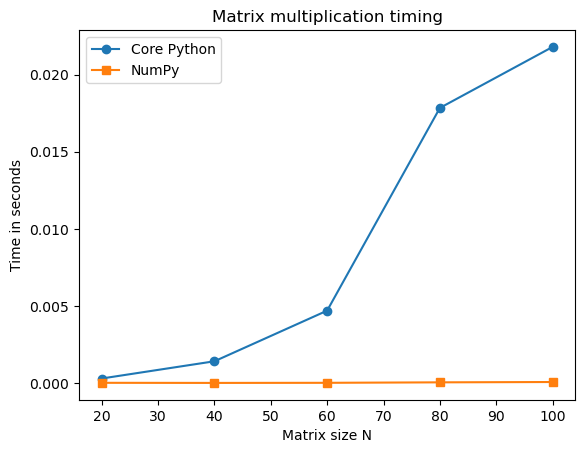

In [10]:
import numpy as np
import time
import matplotlib.pyplot as plt

N_values = [20, 40, 60, 80, 100]
python_times = []
numpy_times = []

for N in N_values:
    A_np, B_np = make_matrices(N)
    A_list = A_np.tolist()
    B_list = B_np.tolist()

    start = time.perf_counter()
    C_py = matmul_python(A_list, B_list)
    python_times.append(time.perf_counter() - start)

    start = time.perf_counter()
    C_np = A_np @ B_np
    numpy_times.append(time.perf_counter() - start)

plt.figure()
plt.plot(N_values, python_times, marker="o", label="Core Python")
plt.plot(N_values, numpy_times, marker="s", label="NumPy")
plt.xlabel("Matrix size N")
plt.ylabel("Time in seconds")
plt.title("Matrix multiplication timing")
plt.legend()
plt.show()


## Why not use C for everything?

C is powerful, but we will not use C for every demo because:

1. **Longer code can hide the numerical idea.** In teaching, the algorithm must stay visible.
2. **Debugging burden is higher.** Compilation, pointer errors, memory leaks, segmentation faults, and indexing bugs can dominate.
3. **Visualization is harder.** Python makes plotting and diagnostics easy.
4. **Interactivity matters.** Numerical methods are best learned by changing parameters and rerunning quickly.
5. **NumPy already uses optimized compiled code.** For many standard array operations, Python plus NumPy is already fast.

The practical workflow is:

```text
Understand the algorithm
        ↓
Prototype in Python
        ↓
Vectorize using NumPy
        ↓
Use C/CUDA only where needed
        ↓
Verify always
```

Numerical programming is not about worshipping one language. It is about choosing the right level of abstraction for the task.


## 15. Short reflection questions

**Q1.** In

$$
C_{ij} = \sum_k A_{ik}B_{kj},
$$

which loop corresponds to the summation index?

**Answer:** The loop over $k$.

---

**Q2.** Given

$$
A =
\begin{bmatrix}
1 & 2\\
3 & 4
\end{bmatrix},
\quad
B =
\begin{bmatrix}
5 & 6\\
7 & 8
\end{bmatrix},
$$

compute $C_{01}$.

**Answer:**

$$
C_{01}=1\times 6 + 2\times 8 = 22.
$$

---

**Q3.** In C row-major storage, what is the one-dimensional index for $A_{ij}$ in an $N \times N$ matrix?

**Answer:**

$$
iN+j.
$$

---

**Q4.** Why can NumPy matrix multiplication be faster than naive C matrix multiplication?

**Answer:** NumPy often calls optimized compiled BLAS routines that use cache blocking, vectorization, and sometimes multithreading. Naive C is compiled, but it may still have poor memory access patterns.

---

**Q5.** Why does transposing $B$ help the C implementation?

**Answer:** It converts a strided column access in $B$ into a contiguous row access in $B^T$, improving cache efficiency.
